# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
sys.path.append('../../lesson3/seminar')
from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from utils import set_seed
from pytorch_lightning import Trainer

sns.set_style('whitegrid')
set_seed(42)

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [16]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=64)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

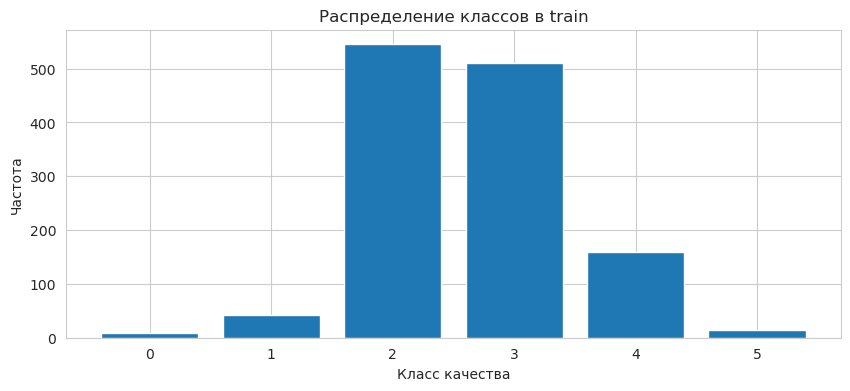

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]
Adjusted class weights: [10.          5.07539683  0.3911315   0.41797386  1.34067086 10.        ]


In [ ]:
train_labels = []
for i in range(len(dm.train_dataset)):
    _, label = dm.train_dataset[i]
    train_labels.append(label.item())
train_labels = np.array(train_labels)

plt.figure(figsize=(10, 4))
plt.hist(train_labels, bins=np.arange(dm.n_classes + 1) - 0.5, rwidth=0.8)
plt.title('Распределение классов в train')
plt.xlabel('Класс качества')
plt.ylabel('Частота')
plt.xticks(range(dm.n_classes))
plt.grid(True, axis='y')
plt.show()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
print(f'Class weights: {class_weights}')

class_weights = np.minimum(class_weights, 10)

print(f'Adjusted class weights: {class_weights}')

## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [18]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='relu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        out = self.activation(out)
        
        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        out = self.activation(out)
        
        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2
        
        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        out = self.activation(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [ ]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.
    
    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.bottleneck_branch = nn.ModuleList([
            BottleneckBlock(hidden_dim, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])
        
        self.inverted_branch = nn.ModuleList([
            InvertedBottleneckBlock(hidden_dim, expansion_factor=4, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])
        
        self.regular_branch = nn.ModuleList([
            RegularBlock(hidden_dim, hidden_dim=hidden_dim * 2, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])
        
        combined_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_proj = nn.Linear(combined_dim, output_dim)
    
    def forward(self, x):
        # 1. Input proj
        x = self.input_proj(x)

        # 2. Forward for each branch
        x1 = x
        for block in self.bottleneck_branch:
            x1 = block(x1)
        
        x2 = x
        for block in self.inverted_branch:
            x2 = block(x2)
        
        x3 = x
        for block in self.regular_branch:
            x3 = block(x3)

        # 3. Concat / Sum results
        if self.combine_mode == 'concat':
            x_combined = torch.cat([x1, x2, x3], dim=1)
        else:  # 'sum'
            x_combined = x1 + x2 + x3

        # 4. Output proj
        x_out = self.output_proj(x_combined)
        return x_out

print('Multi-Branch модель определена!')

Multi-Branch модель определена!


## 4. Код обучение

In [ ]:
def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam'
):
    """
    Обучает модель с weighted loss.
    
    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')
    
    Returns:
        dict с метриками
    """
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()
    
    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )
    
    trainer = Trainer(
        max_epochs=max_epochs,
        enable_checkpointing=False,
        logger=True,
        enable_progress_bar=False,
        enable_model_summary=True
    )
    trainer.fit(lightning_model, dm)
    
    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item(),
    }

## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [ ]:
final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=96,
    output_dim=dm.n_classes,
    num_blocks=2,
    dropout=0.3,
    combine_mode='concat' # concat sum
)

final_results = train_model(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=600,
    lr=0.8e-3,
    optimizer_type='adam'
)

print(f'\n=== Итоговые результаты ===')
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ MultiBranchMLP   │  235 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ metrics │ ModuleDict       │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 40                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 0: accuracy=0.2656, f1_macro=0.1757
Epoch 0: accuracy=0.3281, f1_macro=0.2095
Epoch 1: accuracy=0.3620, f1_macro=0.2253
Epoch 2: accuracy=0.3842, f1_macro=0.2372
Epoch 3: accuracy=0.3956, f1_macro=0.2439
Epoch 4: accuracy=0.3976, f1_macro=0.2442
Epoch 5: accuracy=0.4048, f1_macro=0.2468
Epoch 6: accuracy=0.3995, f1_macro=0.2479
Epoch 7: accuracy=0.4066, f1_macro=0.2509
Epoch 8: accuracy=0.4126, f1_macro=0.2552
Epoch 9: accuracy=0.4207, f1_macro=0.2595
Epoch 10: accuracy=0.4211, f1_macro=0.2599
Epoch 11: accuracy=0.4236, f1_macro=0.2618
Epoch 12: accuracy=0.4251, f1_macro=0.2628
Epoch 13: accuracy=0.4277, f1_macro=0.2645
Epoch 14: accuracy=0.4288, f1_macro=0.2651
Epoch 15: accuracy=0.4306, f1_macro=0.2661
Epoch 16: accuracy=0.4362, f1_macro=0.2692
Epoch 17: accuracy=0.4353, f1_macro=0.2686
Epoch 18: accuracy=0.4386, f1_macro=0.2704
Epoch 19: accuracy=0.4409, f1_macro=0.2718
Epoch 20: accuracy=0.4430, f1_macro=0.2731
Epoch 21: accuracy=0.4457, f1_macro=0.2745
Epoch 22: accuracy=0.4

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 599: accuracy=0.6234, f1_macro=0.3918

=== Итоговые результаты ===
F1 score: 0.3918
Accuracy: 0.6234
